In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [2]:
X,y= make_moons(100,noise=0.25,random_state=42)

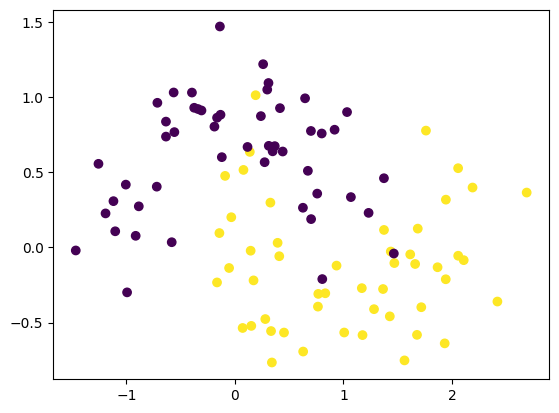

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [16]:
model=Sequential()
model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))

model.add(Dense(1,activation='sigmoid'))

In [17]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_19 (Dense)            (None, 10)                30        
                                                                 
 dense_20 (Dense)            (None, 10)                110       
                                                                 
 dense_21 (Dense)            (None, 10)                110       
                                                                 
 dense_22 (Dense)            (None, 10)                110       
                                                                 
 dense_23 (Dense)            (None, 1)                 11        
                                                                 
Total params: 371 (1.45 KB)
Trainable params: 371 (1.45 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [18]:
model.get_weights()

[array([[-1.0906138 , -0.94740075,  0.7768293 ,  0.42626974,  0.22706343,
         -0.5060285 ,  1.7296822 , -0.30041796,  0.7666008 , -0.02566   ],
        [ 0.52507126,  0.80465764, -1.1079222 , -1.2880152 , -0.7367858 ,
          0.65675294,  0.7033756 , -0.74269414,  1.7239428 , -1.8416578 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.1841027 ,  0.2607576 , -0.52137995,  0.54767525,  0.73726207,
          0.72416013, -0.3198758 ,  0.870119  , -0.3701378 ,  0.2358694 ],
        [ 0.43599564, -0.12567557,  0.10609874, -0.9404093 ,  0.37811145,
         -0.13795345,  0.28269765,  0.27558273, -0.06347732, -0.4034243 ],
        [-0.6977343 , -0.19231726, -0.94413847,  0.10268544,  0.27426538,
         -0.34194902, -0.35408485, -0.4283452 , -0.5264439 ,  0.6085672 ],
        [-0.003348  , -0.4725913 ,  0.42339435,  0.04804441, -0.00315452,
          0.5604105 ,  0.22383587, -0.68332654, -0.26829565,  0.8314005 ],
        [-0.09234

In [19]:
initial_weights = model.get_weights()


In [20]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [21]:
model.set_weights(initial_weights)

In [22]:
model.get_weights()

[array([[-0.71335316, -1.460194  ,  0.13237694,  0.0139376 ,  0.18171203,
          0.29924253, -0.78336376,  0.43716818,  1.0708199 , -0.01622181],
        [-0.14033663, -0.03997155, -0.14815655,  0.75682944,  0.3546819 ,
          0.07183013,  0.11198685,  0.0623913 , -0.34738252,  0.51208925]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.20330982, -0.15747245, -0.1969135 , -0.10009897,  0.32285646,
         -0.20955844,  0.2930705 , -0.07843591,  0.05914701,  0.4907838 ],
        [ 0.25887764,  0.11776268, -0.27134332, -0.22917165, -0.1238668 ,
         -0.17289795, -0.22028501, -0.17385338, -0.12994684,  0.25918055],
        [-0.3897673 ,  0.35347775,  0.11007409, -0.32393125,  0.03558051,
          0.32858726,  0.5747685 ,  0.13405429, -0.07311505,  0.1890332 ],
        [-0.10541587,  0.16561125, -0.15429989, -0.01115736, -0.15307474,
          0.00372423,  0.15015098,  0.01055621, -0.13051601, -0.01803774],
        [-0.28742

In [23]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [24]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100


3/3 [==============================] - 1s 133ms/step - loss: 0.6859 - accuracy: 0.4625 - val_loss: 0.6761 - val_accuracy: 0.5500
Epoch 2/100
3/3 [==============================] - 0s 25ms/step - loss: 0.6825 - accuracy: 0.4625 - val_loss: 0.6736 - val_accuracy: 0.5000
Epoch 3/100
3/3 [==============================] - 0s 23ms/step - loss: 0.6792 - accuracy: 0.4250 - val_loss: 0.6706 - val_accuracy: 0.6000
Epoch 4/100
3/3 [==============================] - 0s 25ms/step - loss: 0.6754 - accuracy: 0.4750 - val_loss: 0.6673 - val_accuracy: 0.6500
Epoch 5/100
3/3 [==============================] - 0s 23ms/step - loss: 0.6714 - accuracy: 0.5375 - val_loss: 0.6640 - val_accuracy: 0.6500
Epoch 6/100
3/3 [==============================] - 0s 20ms/step - loss: 0.6675 - accuracy: 0.6625 - val_loss: 0.6604 - val_accuracy: 0.7500
Epoch 7/100
3/3 [==============================] - 0s 23ms/step - loss: 0.6629 - accuracy: 0.7500 - val_loss: 0.6570 - val_accuracy: 0.7500
Epoch 8/100
3/3 [

In [25]:
model.get_weights()

[array([[-0.93957204, -1.5089908 ,  0.17835689,  0.04332294,  0.16014074,
          0.3486549 , -0.9962043 ,  0.539101  ,  1.1429876 ,  0.06755795],
        [-0.11870295, -0.14493173, -0.36742088,  0.83424807,  0.49841914,
         -0.1294964 ,  0.20103356, -0.16114195, -0.54499334,  0.7033681 ]],
       dtype=float32),
 array([ 0.22939548, -0.20244764,  0.18181221,  0.01424235,  0.07908827,
         0.16897377, -0.02554208,  0.12179653,  0.1403246 ,  0.1347112 ],
       dtype=float32),
 array([[-0.21751794, -0.20333692, -0.21868894,  0.19457604,  0.5635144 ,
         -0.01760253,  0.38525093,  0.2385583 ,  0.08673   ,  0.51656   ],
        [ 0.24325548,  0.07292823, -0.2966419 , -0.14954957,  0.13772346,
          0.12712713, -0.3578606 ,  0.16509666, -0.27766508,  0.25657445],
        [-0.4038665 ,  0.3041778 ,  0.03690797, -0.15122235, -0.02989826,
          0.19023912,  0.7679494 ,  0.10296632,  0.12095557,  0.25474787],
        [-0.14198971,  0.10891986, -0.19581175, -0.1418266 , 

9600/9600 [==============================] - 12s 1ms/step


<Axes: >

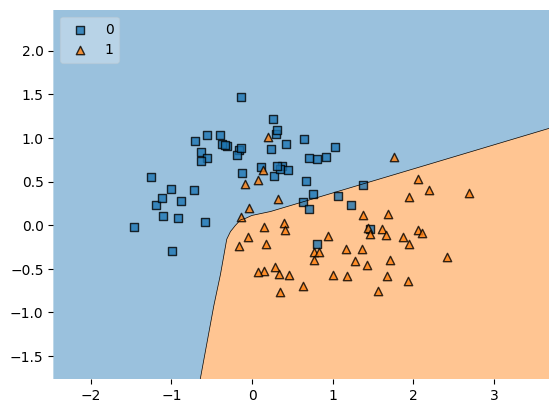

In [26]:
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [27]:
(np.random.randn(10,10)*0.01).min()

-0.028647320338074107

In [28]:
(np.random.randn(10,10)*0.01).max()

0.027818777036899556